In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('Dataset .csv', encoding='utf-8')
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [5]:
print("Missing Latitude:", df['Latitude'].isnull().sum())
print("Missing Longitude:", df['Longitude'].isnull().sum())

df_loc = df.dropna(subset=['Latitude', 'Longitude']).copy()
print(f"Shape after dropping missing coordinates: {df_loc.shape}")

df_loc = df_loc[(df_loc['Latitude'] >= -90) & (df_loc['Latitude'] <= 90) &
                (df_loc['Longitude'] >= -180) & (df_loc['Longitude'] <= 180)]
print(f"Shape after filtering invalid coordinates: {df_loc.shape}")

Missing Latitude: 0
Missing Longitude: 0
Shape after dropping missing coordinates: (9551, 21)
Shape after filtering invalid coordinates: (9551, 21)


Unique cities: 141
Unique localities: 1208


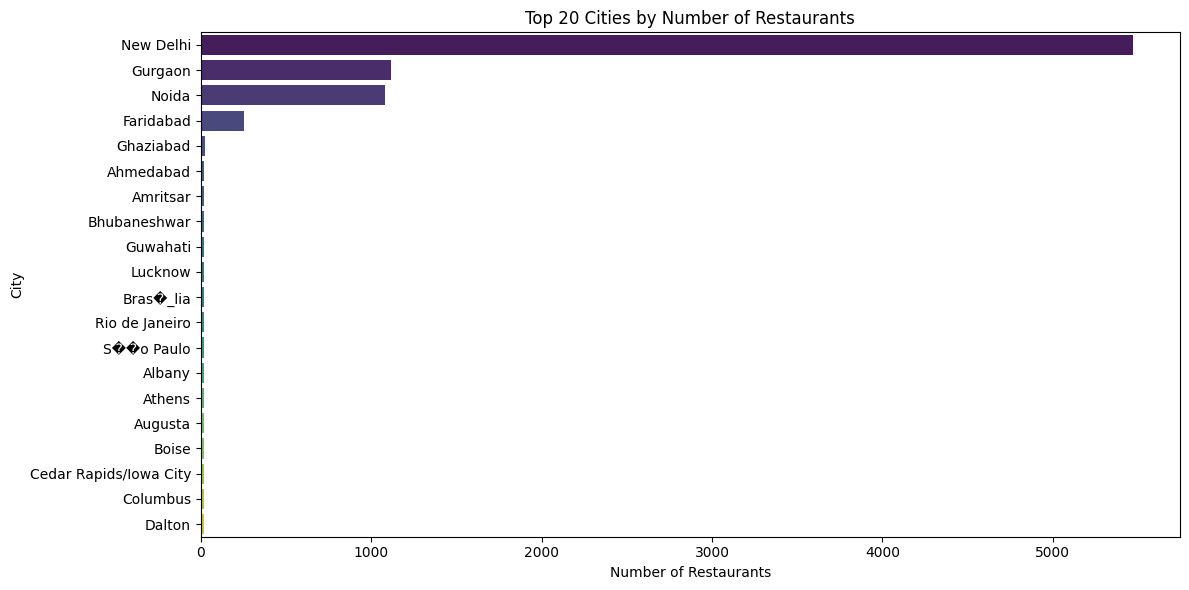

In [6]:
print("Unique cities:", df_loc['City'].nunique())
print("Unique localities:", df_loc['Locality'].nunique())

# Count per city
city_counts = df_loc['City'].value_counts().head(20)
plt.figure(figsize=(12,6))
sns.barplot(x=city_counts.values, y=city_counts.index, palette='viridis')
plt.title('Top 20 Cities by Number of Restaurants')
plt.xlabel('Number of Restaurants')
plt.tight_layout()
plt.show()

In [7]:
mean_lat = df_loc['Latitude'].mean()
mean_lon = df_loc['Longitude'].mean()
map_rest = folium.Map(location=[mean_lat, mean_lon], zoom_start=4)

marker_cluster = MarkerCluster().add_to(map_rest)

for idx, row in df_loc.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=f"{row['Restaurant Name']}<br>{row['City']}<br>Rating: {row['Aggregate rating']}",
        icon=folium.Icon(color='red', icon='info-sign')
    ).add_to(marker_cluster)

# Save map to HTML file
map_rest.save('restaurant_map.html')
print("Map saved as 'restaurant_map.html'. Open in browser to view.")

Map saved as 'restaurant_map.html'. Open in browser to view.


In [8]:
city_stats = df_loc.groupby('City').agg({
    'Restaurant Name': 'count',
    'Aggregate rating': 'mean',
    'Average Cost for two': 'mean',
    'Price range': 'mean',
    'Votes': 'sum'
}).rename(columns={'Restaurant Name': 'Restaurant Count'}).round(2)

# Sort by count descending
city_stats = city_stats.sort_values('Restaurant Count', ascending=False)
city_stats.head(10)

,Restaurant Count,Aggregate rating,Average Cost for two,Price range,Votes
City,,,,,
New Delhi,5473,2.44,596.09,1.62,628340
Gurgaon,1118,2.65,714.02,1.86,132160
Noida,1080,2.04,539.49,1.60,73488
Faridabad,251,1.87,447.61,1.45,6486
Ghaziabad,25,2.85,602.00,1.80,2366
Bhubaneshwar,21,3.98,678.57,1.86,4243
Lucknow,21,4.20,859.52,2.57,9130
Guwahati,21,4.19,821.43,2.52,4964
Ahmedabad,21,4.16,857.14,2.57,12266


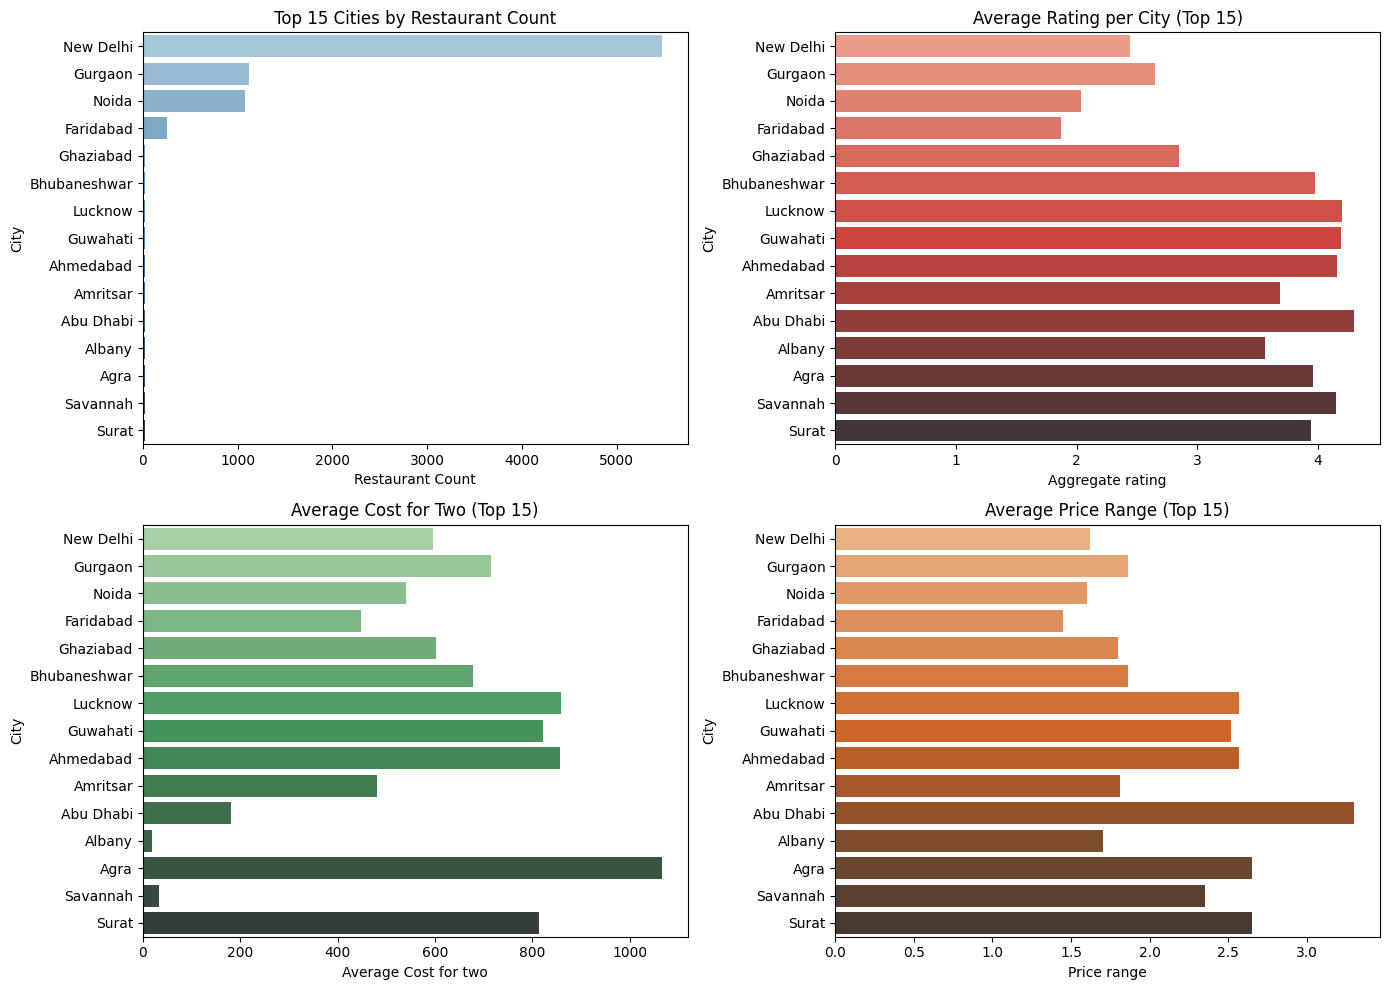

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
top_cities = city_stats.head(15)

# Count
sns.barplot(data=top_cities.reset_index(), x='Restaurant Count', y='City', ax=axes[0,0], palette='Blues_d')
axes[0,0].set_title('Top 15 Cities by Restaurant Count')

# Average Rating
sns.barplot(data=top_cities.reset_index(), x='Aggregate rating', y='City', ax=axes[0,1], palette='Reds_d')
axes[0,1].set_title('Average Rating per City (Top 15)')

# Average Cost
sns.barplot(data=top_cities.reset_index(), x='Average Cost for two', y='City', ax=axes[1,0], palette='Greens_d')
axes[1,0].set_title('Average Cost for Two (Top 15)')

# Average Price Range
sns.barplot(data=top_cities.reset_index(), x='Price range', y='City', ax=axes[1,1], palette='Oranges_d')
axes[1,1].set_title('Average Price Range (Top 15)')

plt.tight_layout()
plt.show()

In [10]:
top5_cities = city_stats.head(5).index.tolist()
df_top5 = df_loc[df_loc['City'].isin(top5_cities)]

locality_stats = df_top5.groupby(['City', 'Locality']).agg({
    'Restaurant Name': 'count',
    'Aggregate rating': 'mean',
    'Average Cost for two': 'mean',
    'Price range': 'mean'
}).rename(columns={'Restaurant Name': 'Restaurant Count'}).round(2)

# Show top 10 localities overall (by count)
top_localities = locality_stats.sort_values('Restaurant Count', ascending=False).head(10)
print("Top 10 Localities by Restaurant Count (in top 5 cities):")
print(top_localities)


Top 10 Localities by Restaurant Count (in top 5 cities):
                               Restaurant Count  Aggregate rating  \
City      Locality                                                  
New Delhi Connaught Place                   122              3.69   
          Rajouri Garden                     99              3.59   
          Shahdara                           87              1.41   
          Defence Colony                     86              3.21   
          Pitampura                          85              2.87   
          Mayur Vihar Phase 1                84              2.03   
          Malviya Nagar                      84              3.42   
          Rajinder Nagar                     81              2.94   
          Safdarjung                         80              2.80   
          Satyaniketan                       79              3.48   

                               Average Cost for two  Price range  
City      Locality                             

In [11]:
from collections import Counter

city_cuisines = {}
for city in top5_cities:
    city_data = df_loc[df_loc['City'] == city]
    # Combine all cuisines strings, split, and count
    all_cuisines = []
    for cuis in city_data['Cuisines'].dropna():
        all_cuisines.extend(cuis.split(', '))
    top_cuis = Counter(all_cuisines).most_common(5)
    city_cuisines[city] = top_cuis

print("Top 5 Cuisines in Major Cities:")
for city, cuis in city_cuisines.items():
    print(f"\n{city}:")
    for c, cnt in cuis:
        print(f"  {c}: {cnt} restaurants")

Top 5 Cuisines in Major Cities:

New Delhi:
  North Indian: 2425 restaurants
  Chinese: 1638 restaurants
  Fast Food: 1304 restaurants
  Mughlai: 628 restaurants
  Bakery: 465 restaurants

Gurgaon:
  North Indian: 508 restaurants
  Chinese: 324 restaurants
  Fast Food: 220 restaurants
  Mughlai: 117 restaurants
  Bakery: 110 restaurants

Noida:
  North Indian: 532 restaurants
  Chinese: 384 restaurants
  Fast Food: 265 restaurants
  Mughlai: 156 restaurants
  Bakery: 93 restaurants

Faridabad:
  North Indian: 122 restaurants
  Chinese: 96 restaurants
  Fast Food: 69 restaurants
  Mughlai: 30 restaurants
  Bakery: 27 restaurants

Ghaziabad:
  North Indian: 10 restaurants
  Fast Food: 8 restaurants
  Chinese: 6 restaurants
  Cafe: 4 restaurants
  Desserts: 3 restaurants


Price Range Percentage in Top 5 Cities:
Price range     1     2     3    4
City                              
New Delhi    55.8  30.3  10.0  3.9
Gurgaon      40.5  39.4  14.1  6.0
Noida        52.3  37.1   8.6  1.9
Faridabad    60.2  34.3   5.6  0.0
Ghaziabad    36.0  52.0   8.0  4.0


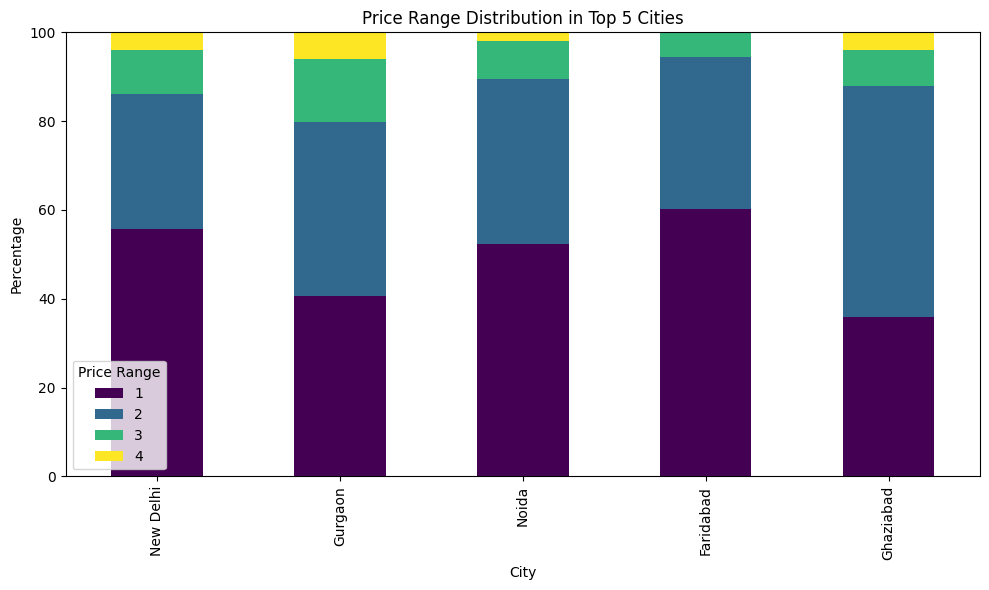

In [12]:
price_by_city = pd.crosstab(df_loc['City'], df_loc['Price range'], normalize='index') * 100
price_by_city_top5 = price_by_city.loc[top5_cities]
print("Price Range Percentage in Top 5 Cities:")
print(price_by_city_top5.round(1))

# Stacked bar chart
price_by_city_top5.plot(kind='bar', stacked=True, figsize=(10,6), colormap='viridis')
plt.title('Price Range Distribution in Top 5 Cities')
plt.ylabel('Percentage')
plt.legend(title='Price Range')
plt.tight_layout()
plt.show()

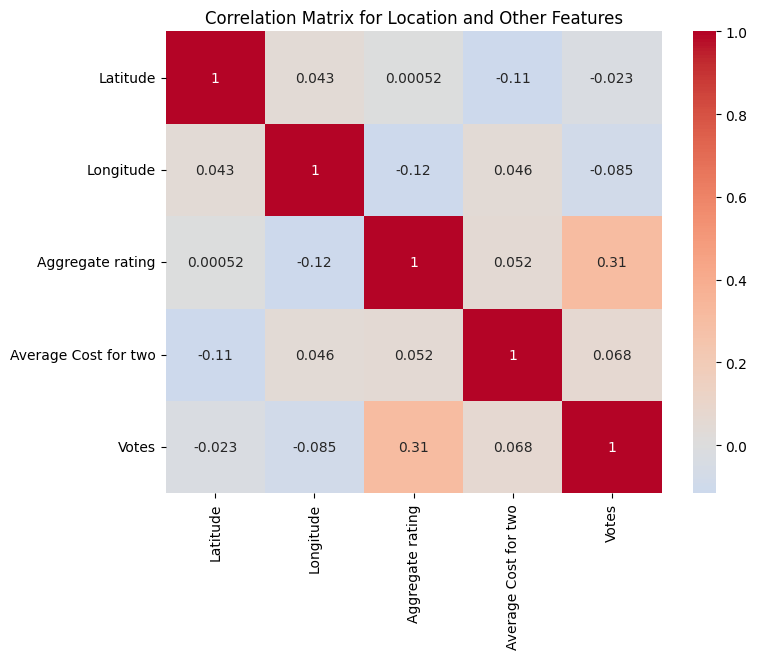

In [13]:
corr = df_loc[['Latitude', 'Longitude', 'Aggregate rating', 'Average Cost for two', 'Votes']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix for Location and Other Features')
plt.show()

In [14]:
print("Key Insights:")
print("- The city with the most restaurants is:", city_stats.index[0])
print("- The city with the highest average rating is:", city_stats['Aggregate rating'].idxmax())
print("- The city with the lowest average rating is:", city_stats['Aggregate rating'].idxmin())
print("- The most expensive city (avg cost) is:", city_stats['Average Cost for two'].idxmax())
print("- The least expensive city (avg cost) is:", city_stats['Average Cost for two'].idxmin())
print("\nCheck the saved map 'restaurant_map.html' for spatial distribution.")

Key Insights:
- The city with the most restaurants is: New Delhi
- The city with the highest average rating is: Inner City
- The city with the lowest average rating is: Faridabad
- The most expensive city (avg cost) is: Jakarta
- The least expensive city (avg cost) is: Miller

Check the saved map 'restaurant_map.html' for spatial distribution.


In [15]:
df_loc.to_csv('restaurants_with_location.csv', index=False)
print("Processed data saved to 'restaurants_with_location.csv'")

Processed data saved to 'restaurants_with_location.csv'
